In [1]:
import numpy as np
import pandas as pd
import cvaefirst
import functions
from mplsoccer import Pitch
import json 
from pathlib import Path
import os
import importlib, cvaefirst
importlib.reload(cvaefirst)


DATA_ROOT = Path(os.environ["EXJOBB_DATA"])
sb_root = DATA_ROOT / "open-data-master" / "data"
comps = pd.read_json(sb_root / "competitions.json")
comps, matches_df, events_df = cvaefirst.load_all_events_1516(sb_root)

NONPLAY = {
    "Starting XI","Half Start","Half End","Tactical Shift",
    "Injury Stoppage","Referee Ball-Drop"
}

df = events_df.copy()
DROP_TYPES = {
    "Starting XI","Half Start","Half End",
    "Ball Receipt*",
    "Substitution","Player On","Player Off",
    "Bad Behaviour","Own Goal For","Own Goal Against",
    "Injury Stoppage","Tactical Shift","Referee Ball-Drop",
    # v1 choice:
    "Pressure",
}
KEEP_TYPES = {"Pass", "Carry", "Dribble", "Shot", "Miscontrol", "Dispossessed"}

KEEP = {"Pass","Carry","Dribble","Shot","Miscontrol","Dispossessed",
              "Foul Won","Foul Committed","Ball Recovery","Interception","Duel","Block","Clearance"}
df = df[df["type"].isin(KEEP)].copy()

df = df.sort_values(["match_id","period","minute","second","event_index"]).reset_index(drop=True)
df["dt"] = df.groupby(["match_id","period","possession"])["t_abs_sec"].diff().fillna(0).clip(lower=0)

# bin it (tune later)
bins = [-1, 1, 3, 7, 15, 1e9]
labels = ["0-1", "1-3", "3-7", "7-15", "15+"]
df["dt_bin"] = pd.cut(df["dt"], bins=bins, labels=labels)
df["dt_bin"] = df["dt_bin"].astype(str)  # for vocab building later

df["start_zone"] = df.apply(lambda r: functions.get_zone(r["x"], r["y"]), axis=1)

df["end_zone"] = df.apply(
    lambda r: functions.get_zone(r["endx"], r["endy"]) if pd.notna(r["endx"]) and pd.notna(r["endy"]) else "NA_END",
    axis=1
)


df["outcome_v1"] = df.apply(cvaefirst.v1_outcome, axis=1)

In [2]:
sequences, seq_meta = cvaefirst.build_possession_sequences(df, max_T=40)
all_types, all_sz, all_ez, all_out, all_dt, all_term = [], [], [], [], [], []

for seq in sequences:
    for s in seq:
        all_types.append(s["type"])
        all_sz.append(s["sz"])
        all_ez.append(s["ez"])
        all_out.append(s["out"])
        all_dt.append(s["dt"])
        all_term.append(s["term"])

type2id = cvaefirst.build_vocab(all_types)
sz2id   = cvaefirst.build_vocab(all_sz)
ez2id   = cvaefirst.build_vocab(all_ez)     # includes NA_END
out2id  = cvaefirst.build_vocab(all_out)
dt2id   = cvaefirst.build_vocab(all_dt)
term2id = cvaefirst.build_vocab(all_term)   # includes NA_TERM + shot/turnover/etc

role2id = {"PAD": 0, "ATT": 1, "DEF": 2}
id2role = {v: k for k, v in role2id.items()}
n_role = len(role2id)
id2type = {v:k for k,v in type2id.items()}
id2sz   = {v:k for k,v in sz2id.items()}
id2ez   = {v:k for k,v in ez2id.items()}
id2out  = {v:k for k,v in out2id.items()}
id2dt   = {v:k for k,v in dt2id.items()}
id2term = {v:k for k,v in term2id.items()}
import math

NAN2 = [float("nan"), float("nan")]
ZERO2 = [0.0, 0.0]

def seq_to_ids(seq):
    out = {
        "role": [role2id[s["role"]] for s in seq],
        "type": [type2id[s["type"]] for s in seq],
        "sz":   [sz2id[s["sz"]] for s in seq],
        "ez":   [ez2id[s["ez"]] for s in seq],
        "out":  [out2id[s["out"]] for s in seq],
        "dt":   [dt2id[s["dt"]] for s in seq],
        "term": [term2id[s["term"]] for s in seq],
    }
    out["dxy"] = [s.get("dxy", ZERO2) for s in seq]

    # xy0: should exist for all events if you have x,y; but if missing, use NaN
    out["xy0"] = [s.get("xy0", NAN2) for s in seq]

    # xy1: should be NaN for non-move events
    out["xy1"] = [s.get("xy1", NAN2) for s in seq]

    return out
seq_ids = [seq_to_ids(seq) for seq in sequences]

is_move = df["type"].isin(["Pass","Carry"])
df.loc[~is_move, ["endx","endy"]] = np.nan

df["end_zone"] = df.apply(
    lambda r: functions.get_zone(r["endx"], r["endy"]) if pd.notna(r["endx"]) and pd.notna(r["endy"]) else "NA_END",
    axis=1
)

# REMOVE u_end_x/u_end_y completely

In [11]:
print(seq_ids[0].keys())
print(seq_ids[0]["xy0"][0], seq_ids[0]["xy1"][0])

dict_keys(['role', 'type', 'sz', 'ez', 'out', 'dt', 'term', 'dxy', 'xy0', 'xy1'])
[61.0, 40.1] [60.2, 40.7]


In [3]:
from prem1516 import build_team_match_features_1516
team_match = build_team_match_features_1516(sb_root) 

Premier League | 2015/2016:   0%|          | 0/380 [00:00<?, ?it/s]/Users/stefanivchenko/code/exjobb/functions.py:344: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c] = df[c].astype("Int64")
/Users/stefanivchenko/code/exjobb/functions.py:345: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pass_width"] = abs(df["endy"] - 40)
Premier League | 2015/2016:   0%|          | 1/380 [00:00<01:06,  5.73it/s]/Users/stefanivchenko/code/exjobb/functions.py:344: SettingWithCopyWarning: 
A value is trying to be set

In [4]:
import torch
KEYS = ["match_id", "possession", "possession_team_id"]


df2 = df.copy()

# role relative to possession owner
df2["role"] = np.where(df2["team_id"] == df2["possession_team_id"], "ATT", "DEF")

# sort chronologically
df2 = df2.sort_values(["match_id","period","minute","second","event_index"])

# pick the first ATT event in each possession that has a location/zone
first_att = (
    df2[df2["role"].eq("ATT") & df2["start_zone"].notna()]
    .groupby(KEYS, as_index=False)
    .first()
)

start_ctx = first_att[KEYS + ["start_zone","minute","x","y","period"]].rename(columns={
    "start_zone": "seq_start_zone",
    "minute": "seq_start_minute",
    "x": "seq_start_x",
    "y": "seq_start_y",
    "period": "seq_start_period",
})

# minute bin
start_ctx["seq_minute_bin"] = pd.cut(
    start_ctx["seq_start_minute"],
    bins=[-1, 15, 30, 45, 60, 75, 200],
    labels=["0-15","15-30","30-45","45-60","60-75","75+"]
).astype(str)

# merge into seq_meta
seq_meta = seq_meta.merge(start_ctx, on=KEYS, how="left")

# --- PATCH: fill rare missing start context (fallback to first event in possession) ---
KEYS = ["match_id", "possession", "possession_team_id"]

df2 = df.sort_values(["match_id","period","minute","second","event_index"])

fallback = (
    df2[df2["start_zone"].notna()]
    .groupby(KEYS, as_index=False)
    .first()[KEYS + ["start_zone","minute"]]
    .rename(columns={"start_zone":"fb_start_zone", "minute":"fb_minute"})
)

seq_meta = seq_meta.merge(fallback, on=KEYS, how="left")

mask = seq_meta["seq_start_zone"].isna()
seq_meta.loc[mask, "seq_start_zone"] = seq_meta.loc[mask, "fb_start_zone"]
seq_meta.loc[mask, "seq_start_minute"] = seq_meta.loc[mask, "fb_minute"]

mask2 = seq_meta["seq_minute_bin"].isna()
seq_meta.loc[mask2, "seq_minute_bin"] = pd.cut(
    seq_meta.loc[mask2, "seq_start_minute"],
    bins=[-1, 15, 30, 45, 60, 75, 200],
    labels=["0-15","15-30","30-45","45-60","60-75","75+"]
).astype(str)

seq_meta = seq_meta.drop(columns=["fb_start_zone","fb_minute"], errors="ignore")

assert seq_meta["seq_start_zone"].notna().all()
assert seq_meta["seq_minute_bin"].notna().all()
# --- end patch ---

tm = team_match.copy()
# build opponent lookup: each match should have exactly 2 teams
opp = (tm[["match_id","team_id"]]
       .merge(tm[["match_id","team_id"]], on="match_id", suffixes=("_own","_opp")))

opp = opp[opp["team_id_own"] != opp["team_id_opp"]].drop_duplicates()

# now join opponent id back onto team rows
tm2 = tm.merge(
    opp.rename(columns={"team_id_own":"team_id", "team_id_opp":"opp_team_id"})[["match_id","team_id","opp_team_id"]],
    on=["match_id","team_id"],
    how="left"
)
feat_cols = ["mean_width", "directness", "tempo", "press_intensity", "press_height_mean_x"
, "mean_pass_length"]

assert tm2["opp_team_id"].notna().all(), "Some teams have no opponent mapped (check matches with != 2 teams)."
own = tm2[["match_id","team_id","opp_team_id"] + feat_cols].copy()
own.columns = ["match_id","team_id","opp_team_id"] + [f"own_{c}" for c in feat_cols]

opp_feats = tm2[["match_id","team_id"] + feat_cols].copy()
opp_feats.columns = ["match_id","opp_team_id"] + [f"opp_{c}" for c in feat_cols]

pair = own.merge(opp_feats, on=["match_id","opp_team_id"], how="left")

# sanity
assert pair[[f"opp_{c}" for c in feat_cols]].notna().all().all(), "Missing opponent feature rows."

seq_meta2 = seq_meta.rename(columns={"possession_team_id":"team_id"}).copy()

seq_with_c = seq_meta2.merge(
    pair,
    on=["match_id","team_id"],
    how="left"
)

seq_with_c["seq_start_zone"] = seq_with_c["seq_start_zone"].fillna("UNK_ZONE")
seq_with_c["seq_minute_bin"] = seq_with_c["seq_minute_bin"].fillna("UNK_MIN")
zone_cat = seq_with_c["seq_start_zone"].astype("category")
minute_cat = seq_with_c["seq_minute_bin"].astype("category")

start_zone_code = zone_cat.cat.codes.to_numpy()
minute_code     = minute_cat.cat.codes.to_numpy()

n_zones = len(zone_cat.cat.categories)
n_mins  = len(minute_cat.cat.categories)

print("n_zones:", n_zones, "n_mins:", n_mins)
assert len(start_zone_code) == len(seq_with_c)
assert len(minute_code) == len(seq_with_c)

missing = seq_with_c[[f"own_{c}" for c in feat_cols] + [f"opp_{c}" for c in feat_cols]].isna().any(axis=1).sum()
print("Sequences missing conditioning:", missing)
cond_cols = [f"own_{c}" for c in feat_cols] + [f"opp_{c}" for c in feat_cols]
seq_with_c = seq_with_c.dropna(subset=cond_cols).reset_index(drop=True)

C = seq_with_c[cond_cols].astype(float).to_numpy()

mu = np.nanmean(C, axis=0)
sd = np.nanstd(C, axis=0)
sd[sd == 0] = 1.0

Cz = (C - mu) / sd

def build_ez_bbox_tensor_from_id2ez(id2ez_dict, zone_bbox_fn, device="cpu"):
    # id2ez_dict: {int_id: "ZoneName"}
    n = max(id2ez_dict.keys()) + 1
    bb = torch.zeros((n, 4), dtype=torch.float32)

    for i, zone_name in id2ez_dict.items():
        if not isinstance(zone_name, str):
            bb[i] = torch.tensor([0.0, 120.0, 0.0, 80.0])
            continue

        b = zone_bbox_fn(zone_name)
        if b is None:
            bb[i] = torch.tensor([0.0, 120.0, 0.0, 80.0])
        else:
            x0, x1, y0, y1 = b
            bb[i] = torch.tensor([float(x0), float(x1), float(y0), float(y1)])

    return bb.to(device)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
EZ_BB = build_ez_bbox_tensor_from_id2ez(id2ez, cvaefirst.zone_bbox, device=device)

n_zones: 26 n_mins: 6
Sequences missing conditioning: 0


In [11]:
from torch.utils.data import DataLoader
import torch

T = 40
from torch.utils.data import DataLoader, Subset
good = ~np.isnan(Cz).any(axis=1)
seq_ids = [seq_ids[i] for i in range(len(seq_ids)) if good[i]]
Cz = Cz[good]
start_zone_code = start_zone_code[good]
minute_code = minute_code[good]
N = len(seq_ids)
idx = np.arange(N)
rng = np.random.default_rng(0)
rng.shuffle(idx)

n_train = int(0.80 * N)
n_val   = int(0.10 * N)

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

ds_all = cvaefirst.PossessionDataset(seq_ids, Cz, start_zone_code, minute_code, T=40)

train_ds = Subset(ds_all, train_idx)
val_ds   = Subset(ds_all, val_idx)
test_ds  = Subset(ds_all, test_idx)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=0, drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0, drop_last=False)



print("device:", device)

model = cvaefirst.SeqCVAE(
    n_role=len(role2id),
    n_types=len(type2id),
    n_sz=len(sz2id),
    n_ez=len(ez2id),
    n_out=len(out2id),
    n_dt=len(dt2id),
    n_term=len(term2id),
    n_zones=n_zones,
    n_minbins=n_mins,
    emb=32, hidden=256, zdim=32, cdim=12
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

# KL anneal: ramp beta 0->1 over first 5 epochs
import math
import json

best_median = math.inf
best_epoch = -1

history = {
    "epoch": [],
    "train_loss": [],
    "val_main": [],
    "val_dxy_loss": [],
    "val_median_m": [],
    "val_mean_m": [],
}


LAMBDA_DXY  =1
LAMBDA_ZONE = 1   # start here; try 0.1–0.3
"""
for epoch in range(200):
    beta = min(1.0, epoch / 40)
    ss_prob = min(0.3, epoch / 50)


    train_loss = cvaefirst.train_one_epoch(
        model, train_dl, opt, device,
        type2id,
        beta=beta,
        lambda_dxy=LAMBDA_DXY,
        lambda_soft=0.3,
        ez_bb=EZ_BB,
        ez2id=ez2id,
        lambda_zone=LAMBDA_ZONE,
    )

    val_stats = cvaefirst.eval_one_epoch(
        model, val_dl, device,
        type2id,
        beta=beta,
        lambda_dxy=LAMBDA_DXY,
        lambda_soft=0.1,
        ez_bb=EZ_BB,
        ez2id=ez2id,
        lambda_zone=LAMBDA_ZONE,
    )

    meters = cvaefirst.validate_dxy_meters(
        model=model,
        loader=val_dl,
        device=device,
        type2id=type2id,
        max_batches=None
    )

    median_m = meters["median_m"]
    mean_m   = meters["mean_m"]

    print(
        f"ep {epoch:03d} beta={beta:.2f} "
        f"train={train_loss:.3f} "
        f"val_total={float(val_stats.get('total', float('nan'))):.3f} "
        f"val_main={float(val_stats['main']):.3f} "
        f"val_kld={float(val_stats.get('kld', float('nan'))):.3f} "
        f"val_dxy={float(val_stats['dxy']):.3f} "
        f"val_zone={float(val_stats.get('zone', 0.0)):.3f} "
        f"dxy_med={median_m:.2f}m "
        f"dxy_mean={mean_m:.2f}m"
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_main"].append(float(val_stats["main"]))
    history["val_dxy_loss"].append(float(val_stats["dxy"]))
    history["val_median_m"].append(median_m)
    history["val_mean_m"].append(mean_m)

    # checkpoint on improved median distance
    if not math.isnan(median_m) and median_m < best_median - 0.05:
        best_median = median_m
        best_epoch = epoch

        ckpt = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "opt_state": opt.state_dict(),
            "best_median_m": best_median,
            "type2id": type2id,
            "sz2id": sz2id,
            "ez2id": ez2id,
            "out2id": out2id,
            "dt2id": dt2id,
            "term2id": term2id,
            "role2id": role2id,
        }

        torch.save(ckpt, "best_cvae.pt")
        print(f"  ✅ saved best_cvae.pt (median {best_median:.2f}m at epoch {best_epoch})")
print("Best epoch:", best_epoch, "best median meters:", best_median)

with open("training_history.json", "w") as f:
    json.dump(history, f)
import torch

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt.state_dict(),
    "type2id": type2id,
    "sz2id": sz2id,
    "ez2id": ez2id,
    "out2id": out2id,
    "dt2id": dt2id,
    "term2id": term2id,
    "config": {
        "emb": 32,
        "hidden": 256,
        "zdim": 32,
        "cdim": 12,
        "T": 40
    }
}

torch.save(checkpoint, "cvae_v1_prem1516_startdata.pt")

print("Model saved.")
"""


device: mps


'\nfor epoch in range(200):\n    beta = min(1.0, epoch / 40)\n    ss_prob = min(0.3, epoch / 50)\n\n\n    train_loss = cvaefirst.train_one_epoch(\n        model, train_dl, opt, device,\n        type2id,\n        beta=beta,\n        lambda_dxy=LAMBDA_DXY,\n        lambda_soft=0.3,\n        ez_bb=EZ_BB,\n        ez2id=ez2id,\n        lambda_zone=LAMBDA_ZONE,\n    )\n\n    val_stats = cvaefirst.eval_one_epoch(\n        model, val_dl, device,\n        type2id,\n        beta=beta,\n        lambda_dxy=LAMBDA_DXY,\n        lambda_soft=0.1,\n        ez_bb=EZ_BB,\n        ez2id=ez2id,\n        lambda_zone=LAMBDA_ZONE,\n    )\n\n    meters = cvaefirst.validate_dxy_meters(\n        model=model,\n        loader=val_dl,\n        device=device,\n        type2id=type2id,\n        max_batches=None\n    )\n\n    median_m = meters["median_m"]\n    mean_m   = meters["mean_m"]\n\n    print(\n        f"ep {epoch:03d} beta={beta:.2f} "\n        f"train={train_loss:.3f} "\n        f"val_total={float(val_stat

In [12]:
import torch
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("overnight.pt", map_location=device)


# recreate the model exactly the same way

model = cvaefirst.SeqCVAE(
    n_role=len(role2id),
    n_types=len(type2id),
    n_sz=len(sz2id),
    n_ez=len(ez2id),
    n_out=len(out2id),
    n_dt=len(dt2id),
    n_term=len(term2id),
    n_zones=n_zones,
    n_minbins=n_mins,
    emb=32, hidden=256, zdim=32, cdim=12
).to(device)
model.load_state_dict(ckpt["model_state"])

model = model.to(device)
model.eval()

SeqCVAE(
  (type_emb): Embedding(15, 32, padding_idx=0)
  (sz_emb): Embedding(27, 32, padding_idx=0)
  (ez_emb): Embedding(28, 32, padding_idx=0)
  (out_emb): Embedding(12, 32, padding_idx=0)
  (dt_emb): Embedding(6, 32, padding_idx=0)
  (term_emb): Embedding(6, 32, padding_idx=0)
  (zone_ctx_emb): Embedding(26, 8)
  (min_ctx_emb): Embedding(6, 4)
  (role_emb): Embedding(3, 32, padding_idx=0)
  (dxy_emb): Linear(in_features=2, out_features=32, bias=True)
  (ez_dxy_emb): Embedding(28, 16, padding_idx=0)
  (enc_rnn): GRU(248, 256, batch_first=True)
  (to_mu): Linear(in_features=256, out_features=32, bias=True)
  (to_logv): Linear(in_features=256, out_features=32, bias=True)
  (dec_rnn): GRU(312, 256, batch_first=True)
  (h_dxy): Sequential(
    (0): Linear(in_features=272, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
  (h_type): Linear(in_features=256, out_features=15, bias=True)
  (h_sz): Linear(in_features=256, out_feature

In [13]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def sample_categorical(logits, temperature=1.0):
    if temperature != 1.0:
        logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1).item()

def mask_logits(logits_vec, forbid_ids):
    logits_vec = logits_vec.clone()
    for i in forbid_ids:
        if i is not None and 0 <= i < logits_vec.numel():
            logits_vec[i] = -1e9
    return logits_vec
@torch.no_grad()
def generate_one_fixed(
    model, c_vec, zone_code, min_code,
    type2id, role2id, sz2id, ez2id, out2id, dt2id, term2id,
    T=40, temperature=0.9, device="cpu"
):
    model.eval()

    c  = torch.tensor(c_vec, dtype=torch.float32, device=device).unsqueeze(0)
    zc = torch.tensor([zone_code], dtype=torch.long, device=device)
    mc = torch.tensor([min_code], dtype=torch.long, device=device)
    cond = model.make_cond(c, zc, mc)

    z = torch.randn((1, model.zdim), device=device)

    END_ID   = type2id["END"]
    PASS_ID  = type2id["Pass"]
    CARRY_ID = type2id["Carry"]

    PAD_ROLE = role2id["PAD"]
    PAD_SZ   = sz2id["PAD"]
    PAD_EZ   = ez2id["PAD"]
    PAD_OUT  = out2id["PAD"]
    PAD_DT   = dt2id["PAD"]
    NA_TERM  = term2id.get("NA_TERM", 0)

    NA_END_EZ = ez2id.get("NA_END", None)

    # Storage for generated (committed) tokens
    x_gen = torch.empty((1, T, 7), dtype=torch.long, device=device)
    x_gen[:, :, 0] = PAD_ROLE
    x_gen[:, :, 1] = 0         # doesn't matter; will be overwritten
    x_gen[:, :, 2] = PAD_SZ
    x_gen[:, :, 3] = PAD_EZ
    x_gen[:, :, 4] = PAD_OUT
    x_gen[:, :, 5] = PAD_DT
    x_gen[:, :, 6] = NA_TERM

    dxy_gen = torch.zeros((1, T, 2), dtype=torch.float32, device=device)

    # BOS vector (you used 0 in training)
    BOS = torch.zeros((7,), dtype=torch.long, device=device)

    prev_ez = None

    for t in range(T):
        # Build shifted-prefix inputs (THIS is the generation equivalent of teacher forcing)
        x_in  = torch.empty_like(x_gen)
        dxy_in = torch.zeros_like(dxy_gen)

        # default all future to PAD-ish
        x_in[:, :, 0] = PAD_ROLE
        x_in[:, :, 1] = 0
        x_in[:, :, 2] = PAD_SZ
        x_in[:, :, 3] = PAD_EZ
        x_in[:, :, 4] = PAD_OUT
        x_in[:, :, 5] = PAD_DT
        x_in[:, :, 6] = NA_TERM

        x_in[:, 0, :] = BOS
        if t > 0:
            x_in[:, 1:t+1, :] = x_gen[:, :t, :]
            dxy_in[:, 1:t+1, :] = dxy_gen[:, :t, :]

        # Decode with correct argument order
        logits = model.decode(x_in=x_in, z=z, cond=cond, dxy_in=dxy_in, ez_for_dxy=None)

        # --- sample type first
        ty = sample_categorical(logits["type"][0, t], temperature)

        # role
        if ty == END_ID:
            role = PAD_ROLE
        else:
            role_logits = mask_logits(logits["role"][0, t], [PAD_ROLE])
            role = sample_categorical(role_logits, temperature)

        # start zone as state
        if t == 0:
            sz = sample_categorical(logits["sz"][0, t], temperature)
        else:
            if prev_ez is None or prev_ez == PAD_EZ or (NA_END_EZ is not None and prev_ez == NA_END_EZ):
                sz = x_gen[0, t-1, 2].item()
            else:
                sz = prev_ez

        # end zone only for pass/carry
        if ty in (PASS_ID, CARRY_ID):
            ez_logits = logits["ez"][0, t]
            forbid = [PAD_EZ]
            if NA_END_EZ is not None:
                forbid.append(NA_END_EZ)
            ez = sample_categorical(mask_logits(ez_logits, forbid), temperature)
        else:
            ez = NA_END_EZ if NA_END_EZ is not None else PAD_EZ

        # out / dt (you can later mask these by type; leaving as-is for now)
        out = sample_categorical(logits["out"][0, t], temperature)
        dt  = sample_categorical(logits["dt"][0, t], temperature)

        # term only for END
        if ty == END_ID:
            sz = PAD_SZ; ez = PAD_EZ; out = PAD_OUT; dt = PAD_DT
            term = sample_categorical(logits["term"][0, t], temperature)
        else:
            term = NA_TERM

        # Commit token
        x_gen[0, t] = torch.tensor([role, ty, sz, ez, out, dt, term], device=device)

        # Commit dxy
        if ty in (PASS_ID, CARRY_ID):
            dxy_gen[0, t] = logits["dxy"][0, t]
        else:
            dxy_gen[0, t] = 0.0

        prev_ez = ez
        if ty == END_ID:
            break

    return {
        "role": x_gen[0, :, 0].tolist(),
        "type": x_gen[0, :, 1].tolist(),
        "sz":   x_gen[0, :, 2].tolist(),
        "ez":   x_gen[0, :, 3].tolist(),
        "out":  x_gen[0, :, 4].tolist(),
        "dt":   x_gen[0, :, 5].tolist(),
        "term": x_gen[0, :, 6].tolist(),
        "dxy":  dxy_gen[0].cpu().tolist(),
    }

In [14]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def validate_pred_ez_dxy_inside_rate(model, loader, ez_bb_tensor, type2id, device):
    model.eval()

    PASS_ID = type2id["Pass"]
    CARRY_ID = type2id["Carry"]

    total = 0
    inside = 0
    mean_pen = 0.0

    for batch in loader:
        x,  dxy_t, xy0_t, xy1_t, c, zc, mc, mask, lengths = batch

        x = x.to(device)
        xy0_t = xy0_t.to(device)
        xy1_t = xy1_t.to(device)
        c = c.to(device)
        zc = zc.to(device)
        mc = mc.to(device)
        

        
        logits, _, _ = model(x, c, zc, mc, xy0_t, xy1_t, lengths)

        type_pred = logits["type"].argmax(dim=-1)         # [B,T]
        pass_mask = (type_pred == PASS_ID) | (type_pred == CARRY_ID)

        ez_pred  = logits["ez"].argmax(dim=-1)            # [B,T]
        dxy_pred = logits["dxy"]                          # [B,T,2]
        xy1_hat  = xy0_t + dxy_pred                       # [B,T,2]

        # flatten
        pass_flat = pass_mask.view(-1)
        if pass_flat.sum().item() == 0:
            continue

        xy1_flat = xy1_hat.view(-1, 2)[pass_flat]
        ez_flat  = ez_pred.view(-1)[pass_flat]

        bb = ez_bb_tensor[ez_flat]                        # [N,4]
        x_hat, y_hat = xy1_flat[:,0], xy1_flat[:,1]
        x0, x1, y0, y1 = bb[:,0], bb[:,1], bb[:,2], bb[:,3]

        px = F.relu(x0 - x_hat) + F.relu(x_hat - x1)
        py = F.relu(y0 - y_hat) + F.relu(y_hat - y1)
        pen = px + py

        inside += (pen == 0).sum().item()
        total  += pen.numel()
        mean_pen += pen.sum().item()

    inside_rate = inside / max(total, 1)
    mean_pen = mean_pen / max(total, 1)

    print(f"Inside rate (Pass/Carry, pred ez): {inside_rate:.3f}")
    print(f"Mean outside penalty: {mean_pen:.3f}")

validate_pred_ez_dxy_inside_rate(model, val_dl, EZ_BB, type2id, device)

Inside rate (Pass/Carry, pred ez): 0.874
Mean outside penalty: 0.669


In [15]:
@torch.no_grad()
def validate_pitch_oob_rate(model, loader, type2id, device):
    model.eval()
    PASS_ID = type2id["Pass"]
    CARRY_ID = type2id["Carry"]

    oob = 0
    tot = 0

    for batch in loader:
        x,  dxy_t, xy0_t, xy1_t, c, zc, mc, mask, lengths = batch
        x=x.to(device); c=c.to(device); zc=zc.to(device); mc=mc.to(device);  xy0_t=xy0_t.to(device); xy1_t=xy1_t.to(device)

        logits, _, _ = model(x, c, zc, mc, xy0_t, xy1_t, lengths)

        type_pred = logits["type"].argmax(dim=-1)
        pass_mask = (type_pred == PASS_ID) | (type_pred == CARRY_ID)

        xy1_hat = xy0_t + logits["dxy"]
        xh, yh = xy1_hat[...,0], xy1_hat[...,1]

        oob_mask = ((xh < 0) | (xh > 120) | (yh < 0) | (yh > 80)) & pass_mask
        oob += oob_mask.sum().item()
        tot += pass_mask.sum().item()

    print("OOB rate (Pass/Carry):", oob / max(tot, 1))

validate_pitch_oob_rate(model, val_dl, type2id, device)

OOB rate (Pass/Carry): 0.013129723368355382


In [16]:
import re
def pretty_print_seq_with_xy_dxy(seq_steps, max_rows=60):
    for t, st in enumerate(seq_steps[:max_rows]):
        if st["type"] == "END":
            print(f"{t:02d} END  term={st['term']}")
            break

        dx, dy = st.get("dxy", (0.0, 0.0))
        print(
            f"{t:02d} {st['role']:3s}  {st['type']:14s}  "
            f"{st['sz']:18s} -> {st['ez']:18s}  "
            f"out={st['out']:10s}  dt={st['dt']:5s}  term={st['term']:10s}  "
            f"dxy=({dx:+.2f},{dy:+.2f})"
        )
def decode_seq_dxy(gen):
    T = len(gen["type"])
    steps = []
    for t in range(T):
        ty = id2type.get(gen["type"][t], "UNK")
        if ty == "PAD":
            break

        dx, dy = (0.0, 0.0)
        if "dxy" in gen:
            dx, dy = gen["dxy"][t]

        steps.append({
            "role": id2role[gen["role"][t]],
            "type": ty,
            "sz":   id2sz[gen["sz"][t]],
            "ez":   id2ez[gen["ez"][t]],
            "out":  id2out[gen["out"][t]],
            "dt":   id2dt[gen["dt"][t]],
            "term": id2term[gen["term"][t]],
            "dxy": (float(dx), float(dy)),
        })

        if ty == "END":
            break
    return steps
def clamp_to_pitch(x, y):
    # StatsBomb pitch is 120 x 80
    x = float(np.clip(x, 0.0, 120.0))
    y = float(np.clip(y, 0.0, 80.0))
    return x, y

def clamp_to_zone_bbox(x, y, zone_name):
    bb = cvaefirst.zone_bbox(zone_name)
    if bb is None:
        return x, y
    x0, x1, y0, y1 = bb
    x = float(np.clip(x, x0, x1))
    y = float(np.clip(y, y0, y1))
    return x, y

def zone_point(zone_name, rng=None, mode="centroid"):
    if rng is None:
        rng = np.random.default_rng(0)
    bb = cvaefirst.zone_bbox(zone_name)
    if bb is None:
        return None
    x0, x1, y0, y1 = bb
    if mode == "centroid":
        return ((x0 + x1) / 2.0, (y0 + y1) / 2.0)
    if mode == "random":
        return (float(rng.uniform(x0, x1)), float(rng.uniform(y0, y1)))
    raise ValueError("mode must be 'centroid' or 'random'")

import numpy as np
from mplsoccer import Pitch

def point_in_zone(pt, zone_name, eps=1e-9):
    """Returns True if (x,y) lies inside the bbox of zone_name."""
    if pt is None or zone_name is None:
        return False
    bb = cvaefirst.zone_bbox(zone_name)
    if bb is None:
        return False
    x, y = pt
    x0, x1, y0, y1 = bb
    return (x0 - eps <= x <= x1 + eps) and (y0 - eps <= y <= y1 + eps)

def safe_zone_point(zone_name, rng, mode="centroid", fallback="pitch"):
    """
    Try to sample/centroid a point in a zone.
    If zone is unknown, fallback to pitch center or random pitch point.
    """
    p = zone_point(zone_name, rng=rng, mode=mode)  # your function
    if p is not None:
        return p

    if fallback == "pitch_center":
        return (60.0, 40.0)
    if fallback == "pitch_random":
        return (float(rng.uniform(0, 120)), float(rng.uniform(0, 80)))
    # default
    return (60.0, 40.0)

def plot_sequence_from_dxy(
    seq,
    seed=0,
    title=None,
    mode_start="centroid",
    enforce_continuity=True,
    enforce_start_zone=False,   # NEW: if True, clamp p0 into sz bbox when possible
    enforce_end_zone=False,     # if True, clamp end point into ez bbox when possible
    clip_pitch=True,
    fallback_start="pitch_center",  # "pitch_center" or "pitch_random"
):
    rng = np.random.default_rng(seed)
    pitch = Pitch(pitch_type="statsbomb")
    fig, ax = pitch.draw(figsize=(10, 6))
    if title:
        ax.set_title(title)

    prev_end = None

    for i, st in enumerate(seq):
        ty = st.get("type")
        if ty == "END":
            break

        role = st.get("role", "ATT")
        is_def = (role == "DEF")
        alpha = 0.5 if is_def else 0.9
        lw = 2.0 if not is_def else 1.5

        sz = st.get("sz")
        ez = st.get("ez")

        # --- START POINT ---
        if enforce_continuity and prev_end is not None:
            # use previous end as start by default
            x0, y0 = prev_end
            # optionally force it back into the declared start-zone bbox
            if enforce_start_zone:
                x0, y0 = clamp_to_zone_bbox(x0, y0, sz)
        else:
            x0, y0 = safe_zone_point(sz, rng=rng, mode=mode_start, fallback=fallback_start)

        if clip_pitch:
            x0, y0 = clamp_to_pitch(x0, y0)

        # --- END POINT ---
        if ty in ("Pass", "Carry"):
            dx, dy = st.get("dxy", (0.0, 0.0))
            x1, y1 = x0 + float(dx), y0 + float(dy)

            if enforce_end_zone:
                x1, y1 = clamp_to_zone_bbox(x1, y1, ez)

            if clip_pitch:
                x1, y1 = clamp_to_pitch(x1, y1)
        else:
            x1, y1 = x0, y0

        # --- DRAW ---
        if ty == "Pass":
            pitch.arrows(
                x0, y0, x1, y1, ax=ax,
                linewidth=lw/3, headwidth=3, headlength=3,
                alpha=alpha
            )
        elif ty == "Carry":
            pitch.lines(
                x0, y0, x1, y1, ax=ax,
                linestyle="dotted", linewidth=lw,
                alpha=alpha
            )
        elif ty == "Shot":
            pitch.arrows(
                x0, y0, 120, 40, ax=ax,
                linewidth=lw, headwidth=3, headlength=3,
                alpha=alpha,
                color="red"
            )
        elif ty in ("Interception", "Block"):
            pitch.scatter([x0], [y0], ax=ax, s=120, marker="x",
                          linewidths=2, zorder=5, alpha=alpha)
        else:
            pitch.scatter([x0], [y0], ax=ax, s=30, alpha=alpha)

        pitch.annotate(str(i), (x0, y0), ax=ax, fontsize=8)

        prev_end = (x1, y1)

    return fig, ax

In [207]:
j=0
x, dxy_t, xy0_t, xy1_t, c_vec, zc, mc, mask, length = ds_all[j]

c_vec = np.zeros(12, dtype=np.float32)

c_vec[1]= 3
c_vec[5] = 3.0   # attacking width very 

gen = generate_one_fixed(model=model, c_vec=c_vec, zone_code=int(zc), min_code=int(mc),
    type2id=type2id,
    role2id=role2id,
    sz2id=sz2id,
    ez2id=ez2id,
    out2id=out2id,
    dt2id=dt2id,
    term2id=term2id,
    T=40,
    temperature=0.01,
    device=device,
)
seq = decode_seq_dxy(gen)

pretty_print_seq_with_xy_dxy(seq)



00 ATT  Duel            Center_Dead_Att    -> NA_END              out=NA          dt=0-1    term=NA_TERM     dxy=(+0.00,+0.00)
01 ATT  Ball Recovery   Center_Dead_Att    -> NA_END              out=NA          dt=0-1    term=NA_TERM     dxy=(+0.00,+0.00)
02 ATT  Carry           Center_Dead_Att    -> Center_Dead_Att     out=NA          dt=0-1    term=NA_TERM     dxy=(+2.06,-7.15)
03 ATT  Pass            Center_Dead_Att    -> Wing_Left_Zone3     out=Incomplete  dt=1-3    term=NA_TERM     dxy=(+4.64,-12.82)
04 DEF  Pass            Wing_Left_Zone4    -> Center_Dead_Att     out=Incomplete  dt=0-1    term=NA_TERM     dxy=(+26.50,+1.53)
05 ATT  Pass            Center_Dead_Att    -> Wing_Right_Zone2    out=NA          dt=1-3    term=NA_TERM     dxy=(+19.53,+18.08)
06 DEF  Pass            Wing_Right_Zone3   -> Center_Dead_Att     out=NA          dt=1-3    term=NA_TERM     dxy=(+13.71,-5.52)
07 END  term=turnover


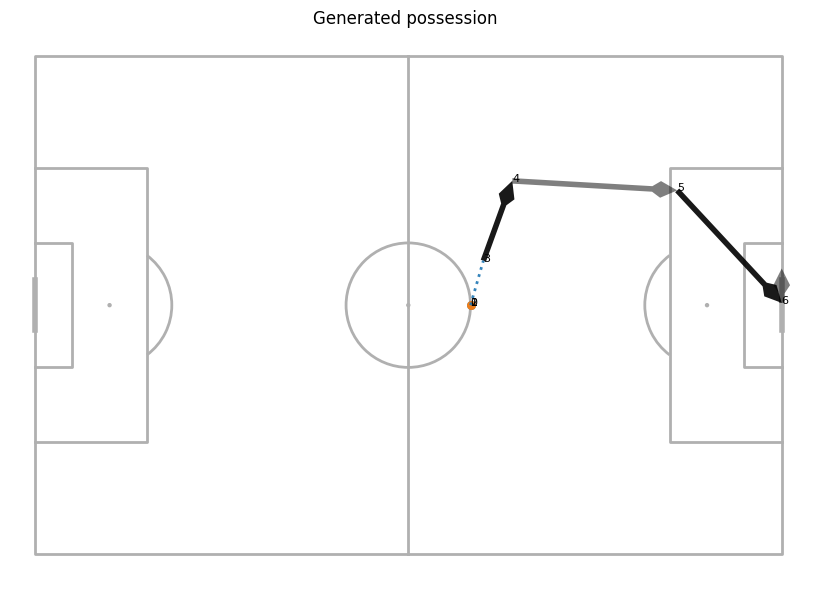

In [208]:
fig, ax = plot_sequence_from_dxy(seq, seed=0, title="Generated possession ")